# J1.2 — data-term identifiability screen

Этот development-only отчёт сравнивает MIND и intensity objectives для шести frozen полей: truth, balanced estimate, glued mean velocity, common scale, zero и inverse truth. Primary decision был заморожен до вычисления; predeclared interior metric используется только для локализации boundary contamination. Held-out challenge не загружен.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_DIR = ARTIFACT_ROOT / "results/piecewise_svf_j12_identifiability_v1"
MANIFEST_PATH = RESULT_DIR / "manifest.json"
SUMMARY_PATH = RESULT_DIR / "summary.csv"
DECISIONS_PATH = RESULT_DIR / "decisions.csv"
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
summary = pd.read_csv(SUMMARY_PATH)
decisions = pd.read_csv(DECISIONS_PATH)

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

print(f"code: {manifest['code_version']}")
print(f"records/cases: {manifest['record_count']}/{manifest['case_count']}")
print(f"classification_counts: {manifest['classification_counts']}")
print(f"challenge_loaded={manifest['challenge']['loaded']}")

code: ced7ee89d7c9bb9282ad8058a2d30ba1f9cdf7e3
records/cases: 36/3
classification_counts: {'direction_failure': 3}
challenge_loaded=False


In [3]:
checks = {
    "screen": sha256(REPO_ROOT / "configs" / manifest["screen_config"]["path"])
    == manifest["screen_config"]["sha256"],
    "suite": sha256(REPO_ROOT / "configs" / manifest["suite_config"]["path"])
    == manifest["suite_config"]["sha256"],
    "development_manifest": sha256(
        ARTIFACT_ROOT / manifest["development_batch_manifest"]["path"]
    )
    == manifest["development_batch_manifest"]["sha256"],
    "external_runner": sha256(REPO_ROOT / "tools" / manifest["external_runner"]["path"])
    == manifest["external_runner"]["sha256"],
    "summary": sha256(SUMMARY_PATH) == manifest["summary_sha256"],
    "decisions": sha256(DECISIONS_PATH) == manifest["decisions_sha256"],
}
for name, expected in manifest["runner_sha256"].items():
    checks[name] = sha256(RESULT_DIR / name) == expected
assert all(checks.values()), checks
pd.Series(checks, name="checksum_match").to_frame()

,checksum_match
screen,True
suite,True
development_manifest,True
external_runner,True
summary,True
decisions,True
dev_contact_counter_rotation__runner.json,True
dev_contact_longitudinal_twist__runner.json,True
dev_contact_shallow_low_texture__runner.json,True


In [4]:
decision_columns = [
    "case_id",
    "warp_direction_pass",
    "mind_slip_identifiable",
    "intensity_slip_identifiable",
    "optimizer_reduced_data_term",
    "truth_to_inverse_mind_ratio_max",
    "truth_to_inverse_intensity_ratio_max",
    "truth_to_zero_mind_ratio_max",
    "truth_to_zero_intensity_ratio_max",
    "truth_to_glued_mind_ratio_max",
    "truth_to_glued_intensity_ratio_max",
    "estimated_to_zero_mind_ratio_max",
    "classification",
]
decisions[decision_columns].style.format({
    column: "{:.3f}" for column in decision_columns if column.endswith("_max")
})

,case_id,warp_direction_pass,mind_slip_identifiable,intensity_slip_identifiable,optimizer_reduced_data_term,truth_to_inverse_mind_ratio_max,truth_to_inverse_intensity_ratio_max,truth_to_zero_mind_ratio_max,truth_to_zero_intensity_ratio_max,truth_to_glued_mind_ratio_max,truth_to_glued_intensity_ratio_max,estimated_to_zero_mind_ratio_max,classification
0,dev_contact_counter_rotation,False,True,False,True,0.163,12.601,0.327,18.572,0.744,0.844,0.543,direction_failure
1,dev_contact_longitudinal_twist,False,False,False,True,0.126,23.214,0.238,61.897,0.894,0.914,0.336,direction_failure
2,dev_contact_shallow_low_texture,False,False,False,False,0.462,16.855,0.927,7.761,0.934,1.062,1.463,direction_failure


In [5]:
indexed = summary.set_index(["case_id", "candidate", "region"])

def maximum_ratio(case_id: str, numerator: str, denominator: str, metric: str) -> float:
    return max(
        indexed.loc[(case_id, numerator, region), metric]
        / indexed.loc[(case_id, denominator, region), metric]
        for region in ("lung", "body")
    )

ratio_rows = []
for case_id in decisions["case_id"]:
    for metric in (
        "mind_mse_full",
        "mind_mse_interior",
        "intensity_mse_full",
        "intensity_mse_interior",
    ):
        ratio_rows.append({
            "case_id": case_id,
            "metric": metric,
            "truth/inverse": maximum_ratio(case_id, "truth", "inverse_truth", metric),
            "truth/zero": maximum_ratio(case_id, "truth", "zero", metric),
            "truth/glued": maximum_ratio(case_id, "truth", "glued_mean_velocity", metric),
            "estimated/zero": maximum_ratio(case_id, "estimated_balanced", "zero", metric),
        })
ratios = pd.DataFrame(ratio_rows)
ratios.style.format({column: "{:.3f}" for column in ratios.columns if "/" in column})

,case_id,metric,truth/inverse,truth/zero,truth/glued,estimated/zero
0,dev_contact_counter_rotation,mind_mse_full,0.163,0.327,0.744,0.543
1,dev_contact_counter_rotation,mind_mse_interior,0.158,0.300,0.631,0.581
2,dev_contact_counter_rotation,intensity_mse_full,12.601,18.572,0.844,22.906
3,dev_contact_counter_rotation,intensity_mse_interior,0.022,0.088,0.586,0.569
4,dev_contact_longitudinal_twist,mind_mse_full,0.126,0.238,0.894,0.336
5,dev_contact_longitudinal_twist,mind_mse_interior,0.151,0.275,0.840,0.408
6,dev_contact_longitudinal_twist,intensity_mse_full,23.214,61.897,0.914,69.457
7,dev_contact_longitudinal_twist,intensity_mse_interior,0.031,0.087,0.746,0.453
8,dev_contact_shallow_low_texture,mind_mse_full,0.462,0.927,0.934,1.463
9,dev_contact_shallow_low_texture,mind_mse_interior,0.510,0.974,0.903,1.607


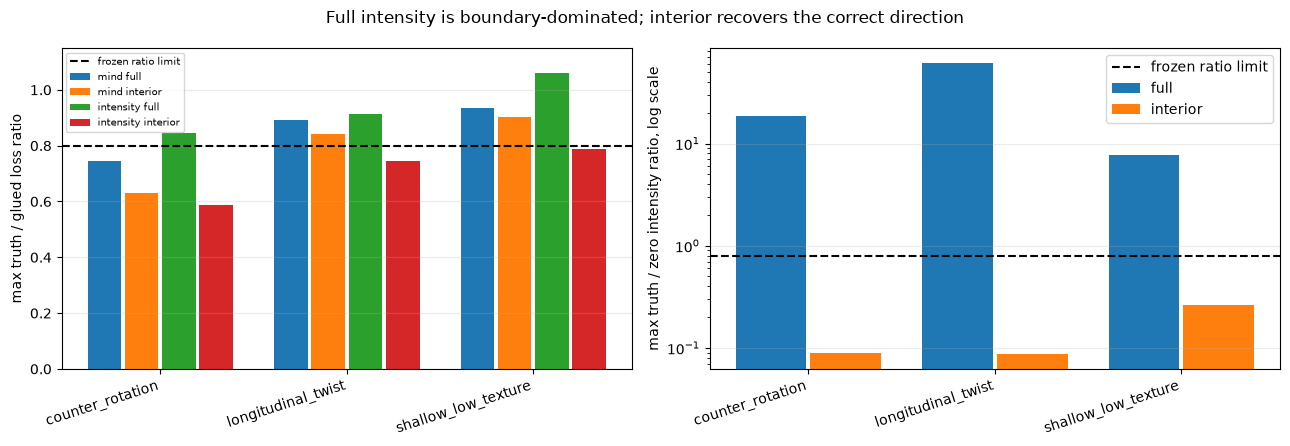

In [6]:
case_labels = decisions["case_id"].str.replace("dev_contact_", "", regex=False)
x = np.arange(len(case_labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for offset, metric in zip(
    (-0.3, -0.1, 0.1, 0.3),
    ("mind_mse_full", "mind_mse_interior", "intensity_mse_full", "intensity_mse_interior"),
    strict=True,
):
    values = ratios.loc[ratios["metric"] == metric, "truth/glued"].to_numpy()
    axes[0].bar(x + offset, values, 0.18, label=metric.replace("_mse_", " "))
axes[0].axhline(0.8, color="black", linestyle="--", label="frozen ratio limit")
axes[0].set_ylabel("max truth / glued loss ratio")
axes[0].set_xticks(x, case_labels, rotation=18, ha="right")
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.25)

for offset, metric in zip(
    (-0.2, 0.2),
    ("intensity_mse_full", "intensity_mse_interior"),
    strict=True,
):
    values = ratios.loc[ratios["metric"] == metric, "truth/zero"].to_numpy()
    axes[1].bar(x + offset, values, 0.38, label=metric.replace("intensity_mse_", ""))
axes[1].axhline(0.8, color="black", linestyle="--", label="frozen ratio limit")
axes[1].set_yscale("log")
axes[1].set_ylabel("max truth / zero intensity ratio, log scale")
axes[1].set_xticks(x, case_labels, rotation=18, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("Full intensity is boundary-dominated; interior recovers the correct direction")
fig.tight_layout()
plt.show()

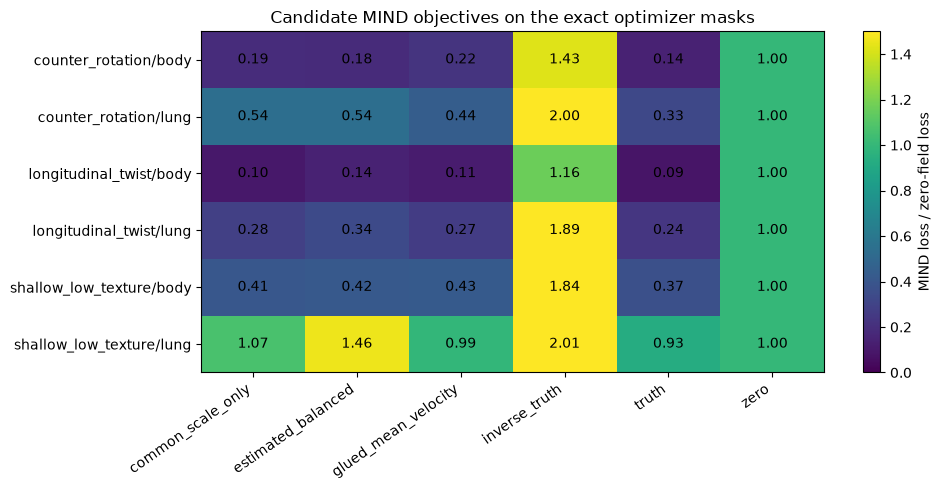

In [7]:
mind_full = summary.pivot_table(
    index=["case_id", "region"],
    columns="candidate",
    values="mind_mse_full",
)
relative = mind_full.div(mind_full["zero"], axis=0)
fig, axis = plt.subplots(figsize=(10, 5))
image = axis.imshow(relative.to_numpy(), cmap="viridis", vmin=0, vmax=1.5, aspect="auto")
axis.set_xticks(np.arange(len(relative.columns)), relative.columns, rotation=35, ha="right")
axis.set_yticks(
    np.arange(len(relative.index)),
    [f"{case.replace('dev_contact_', '')}/{region}" for case, region in relative.index],
)
for row in range(relative.shape[0]):
    for column in range(relative.shape[1]):
        axis.text(column, row, f"{relative.iloc[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=axis, label="MIND loss / zero-field loss")
axis.set_title("Candidate MIND objectives on the exact optimizer masks")
fig.tight_layout()
plt.show()

In [8]:
assert manifest["classification_counts"] == {"direction_failure": 3}
assert not manifest["challenge"]["loaded"]
interior_intensity = ratios[ratios["metric"] == "intensity_mse_interior"]
full_mind = ratios[ratios["metric"] == "mind_mse_full"]
print("FROZEN PRIMARY: direction_failure 3/3")
print("LOCALIZATION: this is boundary contamination, not a reversed transform")
print(
    "interior truth/zero intensity max: "
    f"{interior_intensity['truth/zero'].min():.3f}–{interior_intensity['truth/zero'].max():.3f}"
)
print("counter-rotation: MIND identifies slip, so failure is optimizer/parameterization")
print("twist + shallow: interior intensity identifies slip, MIND does not at ratio 0.8")
print(
    "held-out remains closed; next version must exclude boundary bias and improve "
    "tangential data term"
)

FROZEN PRIMARY: direction_failure 3/3
LOCALIZATION: this is boundary contamination, not a reversed transform
interior truth/zero intensity max: 0.087–0.266
counter-rotation: MIND identifies slip, so failure is optimizer/parameterization
twist + shallow: interior intensity identifies slip, MIND does not at ratio 0.8
held-out remains closed; next version must exclude boundary bias and improve tangential data term
